## Data Understanding & Loading

In [1]:
import numpy as np
import pandas as pd

In [2]:
rides = pd.read_csv("/content/drive/MyDrive/Subject-wise Content | Materials/Programming Materials/AI ML/RNW/7. Data Preprocessing & AI ML/Materials/day 15 & 16 - Live Project - Revision/resources/smartride_rides.csv")
drivers = pd.read_json("/content/drive/MyDrive/Subject-wise Content | Materials/Programming Materials/AI ML/RNW/7. Data Preprocessing & AI ML/Materials/day 15 & 16 - Live Project - Revision/resources/smartride_drivers.json")

In [3]:
rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad
...,...,...,...,...,...,...
4995,4996,2.22,33.03,2026-04-06 17:46:54,Low,Ahmedabad
4996,4997,28.37,230.77,2026-03-29 10:46:54,Medium,Delhi
4997,4998,12.97,252.67,2026-03-16 20:46:54,Medium,Mumbai
4998,4999,10.41,197.99,2026-03-31 19:46:54,Low,Mumbai


In [4]:
drivers

,driver_id,experience,rating
0,1,14,3.98
1,2,14,2.77
2,3,8,4.95
3,4,8,2.61
4,5,13,2.66
...,...,...,...
195,196,5,4.69
196,197,3,4.61
197,198,1,4.02
198,199,13,4.75


In [5]:
# Number of rows and columns

rides.shape

(5000, 6)

In [6]:
# Number of rows and columns

drivers.shape

(200, 3)

In [7]:
# Data types of each feature
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ride_id          5000 non-null   int64  
 1   distance_km      4754 non-null   float64
 2   fare_amount      4523 non-null   float64
 3   pickup_datetime  5000 non-null   object 
 4   traffic_level    4737 non-null   object 
 5   city             5000 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 234.5+ KB


In [8]:
# Data types of each feature
drivers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   driver_id   200 non-null    int64  
 1   experience  200 non-null    int64  
 2   rating      200 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 4.8 KB


In [9]:
# Unique values in categorical columns
rides['traffic_level'].value_counts().index

Index(['Low', 'Medium', 'High'], dtype='object', name='traffic_level')

In [10]:
# Unique values in categorical columns
rides['city'].value_counts().index

Index(['Mumbai', 'Delhi', 'Surat', 'Bangalore', 'Ahmedabad'], dtype='object', name='city')

## Data Cleaning

In [11]:
# Handle missing values in:
  # distance_km
  # fare_amount
  # traffic_level

In [12]:
rides[['distance_km', 'fare_amount', 'traffic_level']].isnull().sum()

,0
distance_km,246
fare_amount,477
traffic_level,263


In [13]:
# Decide appropriate strategies:
  # Mean / Median for numerical
  # Most frequent for categorical

<Axes: xlabel='fare_amount', ylabel='Count'>

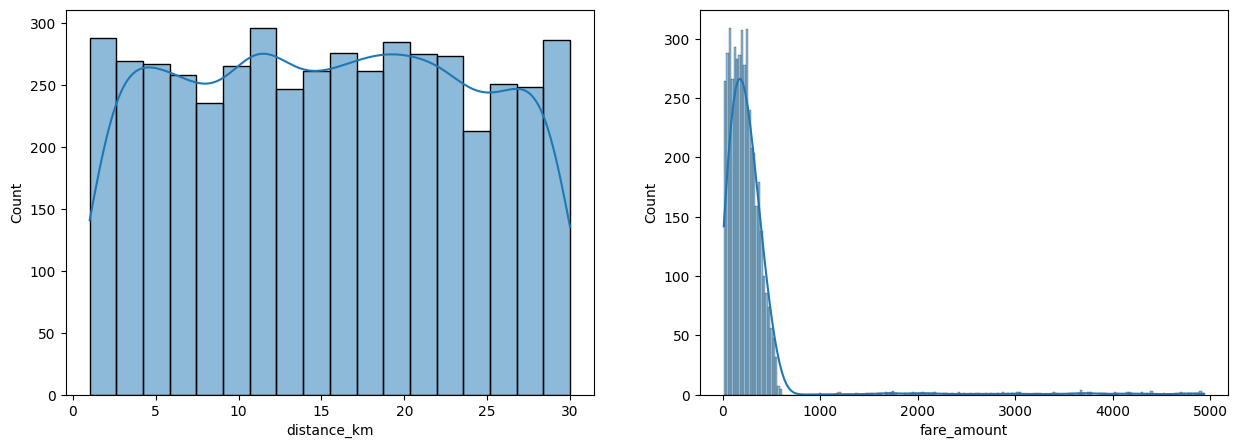

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

_, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(rides['distance_km'], kde=True, ax=axes[0])
sns.histplot(rides['fare_amount'], kde=True, ax=axes[1])

In [15]:
from sklearn.impute import SimpleImputer

mean_imputer = SimpleImputer(strategy="mean")
data = mean_imputer.fit_transform(rides[['distance_km']])

rides['distance_km_mean'] = pd.DataFrame(data, columns=[['distance_km_mean']])

rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,distance_km_mean
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,11.930000
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,11.050000
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,1.480000
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,14.810000
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,22.650000
...,...,...,...,...,...,...,...
4995,4996,2.22,33.03,2026-04-06 17:46:54,Low,Ahmedabad,2.220000
4996,4997,28.37,230.77,2026-03-29 10:46:54,Medium,Delhi,28.370000
4997,4998,12.97,252.67,2026-03-16 20:46:54,Medium,Mumbai,12.970000
4998,4999,10.41,197.99,2026-03-31 19:46:54,Low,Mumbai,10.410000


In [16]:
median_imputer = SimpleImputer(strategy="median")
data = median_imputer.fit_transform(rides[['fare_amount']])

rides['fare_amount_med'] = pd.DataFrame(data, columns=[['fare_amount_med']])

rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,distance_km_mean,fare_amount_med
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,11.930000,135.18
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,11.050000,180.06
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,1.480000,19.51
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,14.810000,147.11
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,22.650000,436.55
...,...,...,...,...,...,...,...,...
4995,4996,2.22,33.03,2026-04-06 17:46:54,Low,Ahmedabad,2.220000,33.03
4996,4997,28.37,230.77,2026-03-29 10:46:54,Medium,Delhi,28.370000,230.77
4997,4998,12.97,252.67,2026-03-16 20:46:54,Medium,Mumbai,12.970000,252.67
4998,4999,10.41,197.99,2026-03-31 19:46:54,Low,Mumbai,10.410000,197.99


In [17]:
mf_imputer = SimpleImputer(strategy="most_frequent")
data = mf_imputer.fit_transform(rides[['traffic_level']])

rides['traffic_level_mf'] = pd.DataFrame(data, columns=[['traffic_level_mf']])

rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,distance_km_mean,fare_amount_med,traffic_level_mf
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,11.930000,135.18,Low
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,11.050000,180.06,High
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,1.480000,19.51,Low
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,14.810000,147.11,High
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,22.650000,436.55,High
...,...,...,...,...,...,...,...,...,...
4995,4996,2.22,33.03,2026-04-06 17:46:54,Low,Ahmedabad,2.220000,33.03,Low
4996,4997,28.37,230.77,2026-03-29 10:46:54,Medium,Delhi,28.370000,230.77,Medium
4997,4998,12.97,252.67,2026-03-16 20:46:54,Medium,Mumbai,12.970000,252.67,Medium
4998,4999,10.41,197.99,2026-03-31 19:46:54,Low,Mumbai,10.410000,197.99,Low


In [18]:
# Convert pickup_datetime into proper datetime format

rides['pickup_datetime'] = pd.to_datetime(rides['pickup_datetime'])

rides.dtypes

,0
ride_id,int64
distance_km,float64
fare_amount,float64
pickup_datetime,datetime64[ns]
traffic_level,object
city,object
distance_km_mean,float64
fare_amount_med,float64
traffic_level_mf,object


In [19]:
# Remove duplicate records

rides.duplicated().sum()

rides.drop_duplicates()

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,distance_km_mean,fare_amount_med,traffic_level_mf
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,11.930000,135.18,Low
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,11.050000,180.06,High
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,1.480000,19.51,Low
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,14.810000,147.11,High
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,22.650000,436.55,High
...,...,...,...,...,...,...,...,...,...
4995,4996,2.22,33.03,2026-04-06 17:46:54,Low,Ahmedabad,2.220000,33.03,Low
4996,4997,28.37,230.77,2026-03-29 10:46:54,Medium,Delhi,28.370000,230.77,Medium
4997,4998,12.97,252.67,2026-03-16 20:46:54,Medium,Mumbai,12.970000,252.67,Medium
4998,4999,10.41,197.99,2026-03-31 19:46:54,Low,Mumbai,10.410000,197.99,Low


In [20]:
rides.describe()

,ride_id,distance_km,fare_amount,pickup_datetime,distance_km_mean,fare_amount_med
count,5000.000000,4754.000000,4523.000000,5000,5000.000000,5000.000000
mean,2500.500000,15.396346,281.926741,2026-03-08 05:19:52.560000,15.396346,274.690008
min,1.000000,1.010000,8.780000,2026-02-05 18:46:54,1.010000,8.780000
25%,1250.750000,8.152500,109.435000,2026-02-21 02:46:54,8.630000,118.717500
50%,2500.500000,15.420000,206.070000,2026-03-08 12:16:54,15.396346,206.070000
75%,3750.250000,22.407500,317.225000,2026-03-23 06:46:54,22.080000,302.882500
max,5000.000000,30.000000,4939.830000,2026-04-07 17:46:54,30.000000,4939.830000
std,1443.520003,8.378683,481.496319,NaN,8.169925,458.490515


## Exploratory Data Analysis (EDA)

In [21]:
# Univariate Analysis:

# Analyze distribution of:
  # distance_km => histplot, boxplot
  # fare_amount => histplot, boxplot
  # traffic_level => countplot

<Axes: xlabel='traffic_level', ylabel='count'>

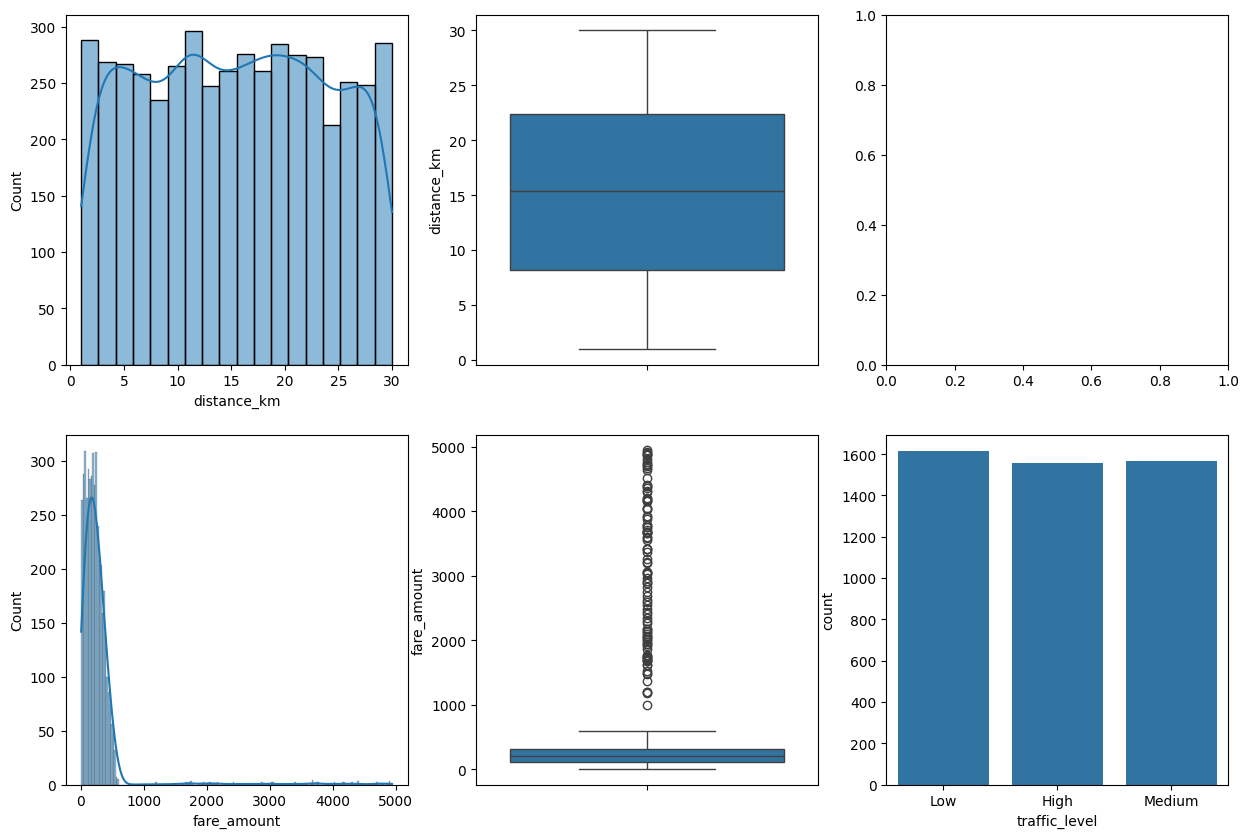

In [22]:
_, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.histplot(rides['distance_km'], kde=True, ax=axes[0, 0])
sns.boxplot(rides['distance_km'], ax=axes[0, 1])

sns.histplot(rides['fare_amount'], kde=True, ax=axes[1, 0])
sns.boxplot(rides['fare_amount'], ax=axes[1, 1])
sns.countplot(x=rides['traffic_level'], ax=axes[1, 2])

In [23]:
# Bivariate Analysis:
  # Relationship between:
    # distance_km vs fare_amount
    # traffic_level vs fare_amount

<Axes: xlabel='traffic_level', ylabel='fare_amount'>

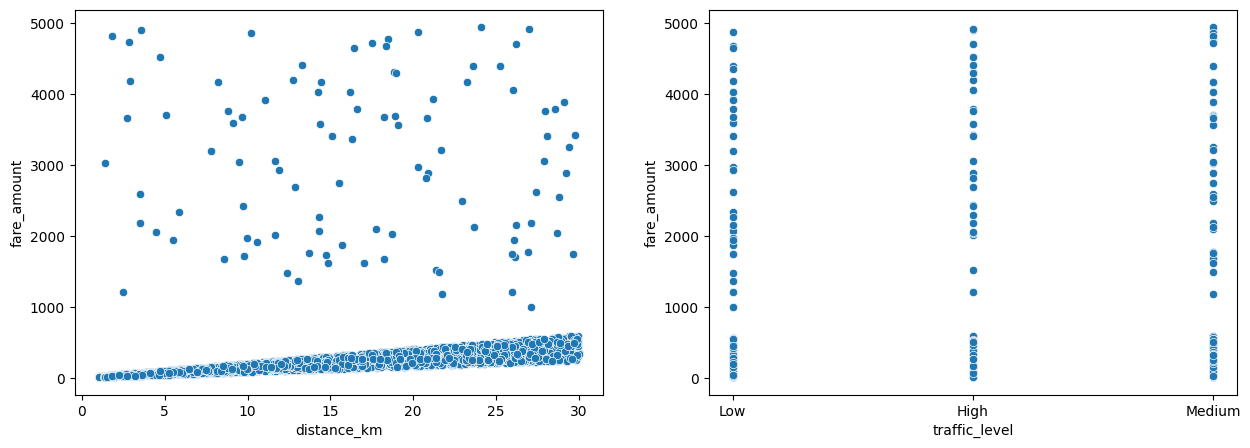

In [24]:
_, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(x=rides['distance_km'], y=rides['fare_amount'], ax=axes[0])
sns.scatterplot(x=rides['traffic_level'], y=rides['fare_amount'], ax=axes[1])

In [25]:
# Multivariate Analysis:
  # Analyze combined effect of:
    # city + traffic + distance on fare
    # Identify patterns, trends, and anomalies

<Axes: >

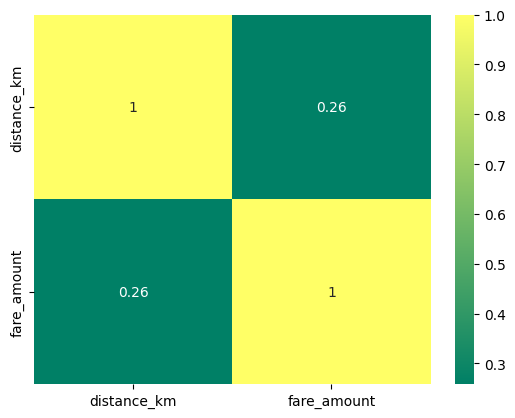

In [26]:
corr_matrix = rides[['distance_km', 'fare_amount']].corr()

sns.heatmap(corr_matrix, annot=True, cmap="summer")

<Axes: xlabel='traffic_level', ylabel='fare_amount'>

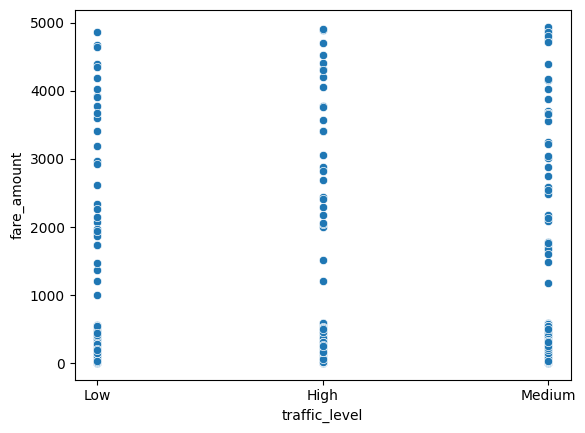

In [27]:
sns.scatterplot(x=rides['traffic_level'], y=rides['fare_amount'])

<Axes: xlabel='city', ylabel='fare_amount'>

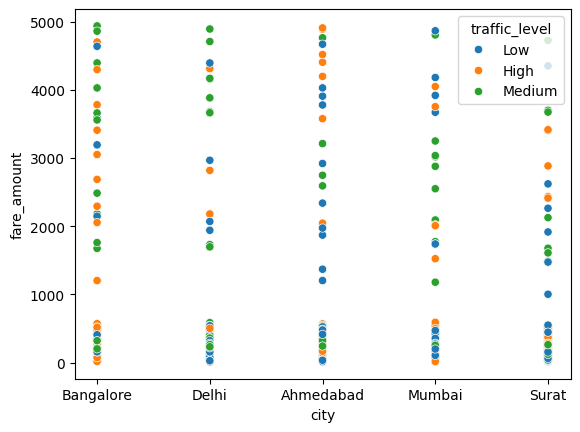

In [28]:
sns.scatterplot(x=rides['city'], y=rides['fare_amount'], hue=rides['traffic_level'])

## Missing Value Treatment

In [29]:
# Apply:
  # Simple Imputer
  # Most Frequent Imputation
  # KNN Imputer
# Compare results of different techniques

In [30]:
rides.head()

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,distance_km_mean,fare_amount_med,traffic_level_mf
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,11.93,135.18,Low
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,11.05,180.06,High
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,1.48,19.51,Low
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,14.81,147.11,High
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,22.65,436.55,High


In [31]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=10)
data = knn_imputer.fit_transform(rides[['distance_km', 'fare_amount']])

new_df = pd.DataFrame(data, columns=[['distance_km_knn', 'fare_amount_knn']])

final_df = pd.concat([rides, new_df], axis=1)
final_df

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,distance_km_mean,fare_amount_med,traffic_level_mf,"(distance_km_knn,)","(fare_amount_knn,)"
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,11.930000,135.18,Low,11.930,135.18
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,11.050000,180.06,High,11.050,180.06
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,1.480000,19.51,Low,1.480,19.51
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,14.810000,147.11,High,14.810,147.11
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,22.650000,436.55,High,22.650,436.55
...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2.22,33.03,2026-04-06 17:46:54,Low,Ahmedabad,2.220000,33.03,Low,2.220,33.03
4996,4997,28.37,230.77,2026-03-29 10:46:54,Medium,Delhi,28.370000,230.77,Medium,28.370,230.77
4997,4998,12.97,252.67,2026-03-16 20:46:54,Medium,Mumbai,12.970000,252.67,Medium,12.970,252.67
4998,4999,10.41,197.99,2026-03-31 19:46:54,Low,Mumbai,10.410000,197.99,Low,10.410,197.99


In [32]:
final_df.describe()

,ride_id,distance_km,fare_amount,pickup_datetime,distance_km_mean,fare_amount_med,"(distance_km_knn,)","(fare_amount_knn,)"
count,5000.000000,4754.000000,4523.000000,5000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,15.396346,281.926741,2026-03-08 05:19:52.560000,15.396346,274.690008,15.361430,281.05509
min,1.000000,1.010000,8.780000,2026-02-05 18:46:54,1.010000,8.780000,1.010000,8.78000
25%,1250.750000,8.152500,109.435000,2026-02-21 02:46:54,8.630000,118.717500,8.127500,111.49000
50%,2500.500000,15.420000,206.070000,2026-03-08 12:16:54,15.396346,206.070000,15.396346,209.45000
75%,3750.250000,22.407500,317.225000,2026-03-23 06:46:54,22.080000,302.882500,22.352500,321.23250
max,5000.000000,30.000000,4939.830000,2026-04-07 17:46:54,30.000000,4939.830000,30.000000,4939.83000
std,1443.520003,8.378683,481.496319,NaN,8.169925,458.490515,8.355736,461.44624


## Outlier Detection & Handling

In [33]:
# Detect outliers using:
  # Z-score method
  # IQR method
# Apply:
  # Percentile method
  # Winsorization
# Analyze impact before and after treatment

In [34]:
mean = rides['fare_amount_med'].mean()
std = rides['fare_amount_med'].std()

rides['z_score'] = (rides['fare_amount_med'] - mean) / std
rides[['fare_amount_med', 'z_score']]

,fare_amount_med,z_score
0,135.18,-0.304281
1,180.06,-0.206395
2,19.51,-0.556566
3,147.11,-0.278261
4,436.55,0.353028
...,...,...
4995,33.03,-0.527077
4996,230.77,-0.095793
4997,252.67,-0.048027
4998,197.99,-0.167288


In [35]:
df_without_outliers = rides[~(rides['z_score'].abs() > 3)]
df_without_outliers

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,distance_km_mean,fare_amount_med,traffic_level_mf,z_score
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,11.930000,135.18,Low,-0.304281
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,11.050000,180.06,High,-0.206395
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,1.480000,19.51,Low,-0.556566
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,14.810000,147.11,High,-0.278261
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,22.650000,436.55,High,0.353028
...,...,...,...,...,...,...,...,...,...,...
4995,4996,2.22,33.03,2026-04-06 17:46:54,Low,Ahmedabad,2.220000,33.03,Low,-0.527077
4996,4997,28.37,230.77,2026-03-29 10:46:54,Medium,Delhi,28.370000,230.77,Medium,-0.095793
4997,4998,12.97,252.67,2026-03-16 20:46:54,Medium,Mumbai,12.970000,252.67,Medium,-0.048027
4998,4999,10.41,197.99,2026-03-31 19:46:54,Low,Mumbai,10.410000,197.99,Low,-0.167288


In [36]:
# IQR Method

Q3 = rides['fare_amount'].quantile(0.75)
Q1 = rides['fare_amount'].quantile(0.25)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5*IQR
upper_fence = Q3 + 1.5*IQR

outliers = rides[(rides['fare_amount'] < lower_fence) | (rides['fare_amount'] > upper_fence)]
outliers

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,distance_km_mean,fare_amount_med,traffic_level_mf,z_score
221,222,9.13,3595.03,2026-02-08 20:46:54,Low,Bangalore,9.130000,3595.03,Low,7.241895
235,236,12.88,2687.96,2026-03-30 19:46:54,High,Bangalore,12.880000,2687.96,High,5.263511
298,299,NaN,2435.55,2026-02-08 13:46:54,High,Surat,15.396346,2435.55,High,4.712987
330,331,13.04,1369.38,2026-03-31 05:46:54,Low,Ahmedabad,13.040000,1369.38,Low,2.387596
448,449,26.93,1774.09,2026-03-18 06:46:54,Medium,Mumbai,26.930000,1774.09,Medium,3.270297
...,...,...,...,...,...,...,...,...,...,...
4818,4819,18.98,4298.84,2026-03-27 08:46:54,High,Bangalore,18.980000,4298.84,High,8.776954
4877,4878,29.10,3884.49,2026-03-31 07:46:54,Medium,Delhi,29.100000,3884.49,Medium,7.873227
4896,4897,17.49,4710.57,2026-02-24 16:46:54,Medium,Delhi,17.490000,4710.57,Medium,9.674966
4908,4909,16.31,3363.86,2026-02-25 23:46:54,NaN,Surat,16.310000,3363.86,Low,6.737697


In [37]:
final_df = rides[~((rides['fare_amount'] < lower_fence) | (rides['fare_amount'] > upper_fence))]
final_df

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,distance_km_mean,fare_amount_med,traffic_level_mf,z_score
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,11.930000,135.18,Low,-0.304281
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,11.050000,180.06,High,-0.206395
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,1.480000,19.51,Low,-0.556566
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,14.810000,147.11,High,-0.278261
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,22.650000,436.55,High,0.353028
...,...,...,...,...,...,...,...,...,...,...
4995,4996,2.22,33.03,2026-04-06 17:46:54,Low,Ahmedabad,2.220000,33.03,Low,-0.527077
4996,4997,28.37,230.77,2026-03-29 10:46:54,Medium,Delhi,28.370000,230.77,Medium,-0.095793
4997,4998,12.97,252.67,2026-03-16 20:46:54,Medium,Mumbai,12.970000,252.67,Medium,-0.048027
4998,4999,10.41,197.99,2026-03-31 19:46:54,Low,Mumbai,10.410000,197.99,Low,-0.167288


In [38]:
# Percentile Method

lower_bound = rides['fare_amount'].quantile(0.05)
upper_bound = rides['fare_amount'].quantile(0.95)

outliers = rides[(rides['fare_amount'] < lower_bound) | (rides['fare_amount'] > upper_bound)]
outliers

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,distance_km_mean,fare_amount_med,traffic_level_mf,z_score
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,1.48,19.51,Low,-0.556566
9,10,2.00,17.34,2026-02-12 22:46:54,Low,Mumbai,2.00,17.34,Low,-0.561298
44,45,1.51,28.52,2026-02-10 23:46:54,Low,Ahmedabad,1.51,28.52,Low,-0.536914
93,94,1.60,27.05,2026-03-13 00:46:54,Medium,Ahmedabad,1.60,27.05,Medium,-0.540120
96,97,26.60,517.13,2026-02-24 05:46:54,Medium,Surat,26.60,517.13,Medium,0.528779
...,...,...,...,...,...,...,...,...,...,...
4955,4956,2.75,3665.47,2026-02-19 03:46:54,Medium,Delhi,2.75,3665.47,Medium,7.395529
4969,4970,1.53,15.31,2026-03-29 10:46:54,High,Mumbai,1.53,15.31,High,-0.565726
4971,4972,1.93,30.45,2026-03-18 12:46:54,Medium,Delhi,1.93,30.45,Medium,-0.532705
4988,4989,27.90,548.57,2026-03-21 05:46:54,Low,Surat,27.90,548.57,Low,0.597351


In [39]:
final_df = rides[~((rides['fare_amount'] < lower_bound) | (rides['fare_amount'] > upper_bound))]
final_df

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,distance_km_mean,fare_amount_med,traffic_level_mf,z_score
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,11.930000,135.18,Low,-0.304281
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,11.050000,180.06,High,-0.206395
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,14.810000,147.11,High,-0.278261
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,22.650000,436.55,High,0.353028
5,6,2.96,47.42,2026-02-13 17:46:54,Low,Delhi,2.960000,47.42,Low,-0.495692
...,...,...,...,...,...,...,...,...,...,...
4995,4996,2.22,33.03,2026-04-06 17:46:54,Low,Ahmedabad,2.220000,33.03,Low,-0.527077
4996,4997,28.37,230.77,2026-03-29 10:46:54,Medium,Delhi,28.370000,230.77,Medium,-0.095793
4997,4998,12.97,252.67,2026-03-16 20:46:54,Medium,Mumbai,12.970000,252.67,Medium,-0.048027
4998,4999,10.41,197.99,2026-03-31 19:46:54,Low,Mumbai,10.410000,197.99,Low,-0.167288


In [40]:
# Winsorization

lower_bound = rides['fare_amount'].quantile(0.05)
upper_bound = rides['fare_amount'].quantile(0.95)

new_df = rides['fare_amount'].clip(lower=lower_bound, upper=upper_bound)
new_df

,fare_amount
0,135.180
1,180.060
2,30.971
3,147.110
4,436.550
...,...
4995,33.030
4996,230.770
4997,252.670
4998,197.990


In [41]:
rides['fare_amount'].describe()

,fare_amount
count,4523.000000
mean,281.926741
std,481.496319
min,8.780000
25%,109.435000
50%,206.070000
75%,317.225000
max,4939.830000


In [42]:
final_df['fare_amount'].describe()

,fare_amount
count,4069.000000
mean,217.009108
std,117.845951
min,30.980000
25%,118.040000
50%,206.070000
75%,303.170000
max,496.780000


## Feature Engineering

In [43]:
# Convert pickup_datetime and extract:
  # Hour
  # Day
  # Month
rides['hour'] = rides['pickup_datetime'].dt.hour
rides['day'] = rides['pickup_datetime'].dt.day
rides['month'] = rides['pickup_datetime'].dt.month

rides[['pickup_datetime', 'hour', 'day', 'month']]

,pickup_datetime,hour,day,month
0,2026-02-05 19:46:54,19,5,2
1,2026-02-27 06:46:54,6,27,2
2,2026-02-17 07:46:54,7,17,2
3,2026-03-19 10:46:54,10,19,3
4,2026-03-01 01:46:54,1,1,3
...,...,...,...,...
4995,2026-04-06 17:46:54,17,6,4
4996,2026-03-29 10:46:54,10,29,3
4997,2026-03-16 20:46:54,20,16,3
4998,2026-03-31 19:46:54,19,31,3


In [44]:
# Create new features:
#   Peak hour indicator
#   Distance category (Short / Medium / Long)

In [45]:
# Peak hour indicator

hour_val = rides['hour'].value_counts().sort_values(ascending=False).values
peak_hours_val = hour_val[hour_val > 215]

peak_hours_val

array([244, 225, 223, 223, 219, 219])

In [46]:
hour_df = rides['hour'].value_counts().sort_values(ascending=False)
peak_hours = hour_df[hour_df > 215].index

peak_hours

Index([22, 20, 19, 6, 10, 16], dtype='int32', name='hour')

In [47]:
rides['peak_hour'] = rides['hour'].apply(lambda x: 'peak_hr' if x in peak_hours else 'normal_hr')

rides[['hour', 'peak_hour']]

,hour,peak_hour
0,19,peak_hr
1,6,peak_hr
2,7,normal_hr
3,10,peak_hr
4,1,normal_hr
...,...,...
4995,17,normal_hr
4996,10,peak_hr
4997,20,peak_hr
4998,19,peak_hr


In [48]:
# Distance category (Short / Medium / Long)

rides['distance_km'].describe()

,distance_km
count,4754.000000
mean,15.396346
std,8.378683
min,1.010000
25%,8.152500
50%,15.420000
75%,22.407500
max,30.000000


In [49]:
def categorize_distance(km):
  if km<=5:
    return "Short"
  elif km<=15:
    return "Medium"
  else:
    return "Long"

rides['distance_category'] = rides['distance_km'].apply(categorize_distance)

rides[['distance_km', 'distance_category']]

,distance_km,distance_category
0,11.93,Medium
1,11.05,Medium
2,1.48,Short
3,14.81,Medium
4,22.65,Long
...,...,...
4995,2.22,Short
4996,28.37,Long
4997,12.97,Medium
4998,10.41,Medium


## Handling Mixed Variables

In [50]:
rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,distance_km_mean,fare_amount_med,traffic_level_mf,z_score,hour,day,month,peak_hour,distance_category
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,11.930000,135.18,Low,-0.304281,19,5,2,peak_hr,Medium
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,11.050000,180.06,High,-0.206395,6,27,2,peak_hr,Medium
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,1.480000,19.51,Low,-0.556566,7,17,2,normal_hr,Short
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,14.810000,147.11,High,-0.278261,10,19,3,peak_hr,Medium
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,22.650000,436.55,High,0.353028,1,1,3,normal_hr,Long
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2.22,33.03,2026-04-06 17:46:54,Low,Ahmedabad,2.220000,33.03,Low,-0.527077,17,6,4,normal_hr,Short
4996,4997,28.37,230.77,2026-03-29 10:46:54,Medium,Delhi,28.370000,230.77,Medium,-0.095793,10,29,3,peak_hr,Long
4997,4998,12.97,252.67,2026-03-16 20:46:54,Medium,Mumbai,12.970000,252.67,Medium,-0.048027,20,16,3,peak_hr,Medium
4998,4999,10.41,197.99,2026-03-31 19:46:54,Low,Mumbai,10.410000,197.99,Low,-0.167288,19,31,3,peak_hr,Medium


In [51]:
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ride_id            5000 non-null   int64         
 1   distance_km        4754 non-null   float64       
 2   fare_amount        4523 non-null   float64       
 3   pickup_datetime    5000 non-null   datetime64[ns]
 4   traffic_level      4737 non-null   object        
 5   city               5000 non-null   object        
 6   distance_km_mean   5000 non-null   float64       
 7   fare_amount_med    5000 non-null   float64       
 8   traffic_level_mf   5000 non-null   object        
 9   z_score            5000 non-null   float64       
 10  hour               5000 non-null   int32         
 11  day                5000 non-null   int32         
 12  month              5000 non-null   int32         
 13  peak_hour          5000 non-null   object        
 14  distance

## Encoding Categorical Data

In [52]:
# Apply:
  # Label Encoding (for city)
  # One Hot Encoding (peak_hour)
  # Ordinal Encoding (for traffic_level)

In [53]:
rides.head()

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,distance_km_mean,fare_amount_med,traffic_level_mf,z_score,hour,day,month,peak_hour,distance_category
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,11.93,135.18,Low,-0.304281,19,5,2,peak_hr,Medium
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,11.05,180.06,High,-0.206395,6,27,2,peak_hr,Medium
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,1.48,19.51,Low,-0.556566,7,17,2,normal_hr,Short
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,14.81,147.11,High,-0.278261,10,19,3,peak_hr,Medium
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,22.65,436.55,High,0.353028,1,1,3,normal_hr,Long


In [54]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

In [55]:
le = LabelEncoder()
data = le.fit_transform(rides[['city']])

rides['city_le'] = pd.DataFrame(data, columns=['city_le'])

rides[['city', 'city_le']]

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,city,city_le
0,Bangalore,1
1,Delhi,2
2,Bangalore,1
3,Bangalore,1
4,Ahmedabad,0
...,...,...
4995,Ahmedabad,0
4996,Delhi,2
4997,Mumbai,3
4998,Mumbai,3


In [56]:
rides['traffic_level'].isnull().sum()

np.int64(263)

In [57]:
oe = OrdinalEncoder(categories=[["Low", "Medium", "High"]])
data = oe.fit_transform(rides[['traffic_level_mf']])

rides['traffic_level_oe'] = pd.DataFrame(data, columns=['traffic_level_oe'])

rides[['traffic_level_mf', 'traffic_level_oe']]

,traffic_level_mf,traffic_level_oe
0,Low,0.0
1,High,2.0
2,Low,0.0
3,High,2.0
4,High,2.0
...,...,...
4995,Low,0.0
4996,Medium,1.0
4997,Medium,1.0
4998,Low,0.0


In [58]:
ohe = OneHotEncoder()
data = ohe.fit_transform(rides[['peak_hour']])

new_df_ohe = pd.DataFrame(data.toarray(), columns=ohe.get_feature_names_out())

ddf = pd.concat([rides, new_df_ohe], axis=1)
ddf

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,distance_km_mean,fare_amount_med,traffic_level_mf,z_score,hour,day,month,peak_hour,distance_category,city_le,traffic_level_oe,peak_hour_normal_hr,peak_hour_peak_hr
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,11.930000,135.18,Low,-0.304281,19,5,2,peak_hr,Medium,1,0.0,0.0,1.0
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,11.050000,180.06,High,-0.206395,6,27,2,peak_hr,Medium,2,2.0,0.0,1.0
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,1.480000,19.51,Low,-0.556566,7,17,2,normal_hr,Short,1,0.0,1.0,0.0
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,14.810000,147.11,High,-0.278261,10,19,3,peak_hr,Medium,1,2.0,0.0,1.0
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,22.650000,436.55,High,0.353028,1,1,3,normal_hr,Long,0,2.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2.22,33.03,2026-04-06 17:46:54,Low,Ahmedabad,2.220000,33.03,Low,-0.527077,17,6,4,normal_hr,Short,0,0.0,1.0,0.0
4996,4997,28.37,230.77,2026-03-29 10:46:54,Medium,Delhi,28.370000,230.77,Medium,-0.095793,10,29,3,peak_hr,Long,2,1.0,0.0,1.0
4997,4998,12.97,252.67,2026-03-16 20:46:54,Medium,Mumbai,12.970000,252.67,Medium,-0.048027,20,16,3,peak_hr,Medium,3,1.0,0.0,1.0
4998,4999,10.41,197.99,2026-03-31 19:46:54,Low,Mumbai,10.410000,197.99,Low,-0.167288,19,31,3,peak_hr,Medium,3,0.0,0.0,1.0


## Numerical Feature Transformation

In [59]:
# Apply:
  # Binning (Discretization)
  # Quantile Binning
  # K-Means Binning

  # Binarization

In [60]:
from sklearn.preprocessing import KBinsDiscretizer

ewb = KBinsDiscretizer(strategy="uniform", encode="ordinal", n_bins=3)
data = ewb.fit_transform(rides[['fare_amount_med']])

rides['fare_amount_ewb'] = pd.DataFrame(data, columns=['fare_amount_ewb'])

print(ewb.bin_edges_[0])

rides[['fare_amount_med', 'fare_amount_ewb']]

[   8.78       1652.46333333 3296.14666667 4939.83      ]


,fare_amount_med,fare_amount_ewb
0,135.18,0.0
1,180.06,0.0
2,19.51,0.0
3,147.11,0.0
4,436.55,0.0
...,...,...
4995,33.03,0.0
4996,230.77,0.0
4997,252.67,0.0
4998,197.99,0.0


In [61]:
from sklearn.preprocessing import KBinsDiscretizer

qb = KBinsDiscretizer(strategy="quantile", encode="ordinal", n_bins=3)
data = qb.fit_transform(rides[['fare_amount_med']])

rides['fare_amount_qb'] = pd.DataFrame(data, columns=['fare_amount_qb'])

print(qb.bin_edges_[0])

rides[['fare_amount_med', 'fare_amount_qb']]

[   8.78        156.65333333  256.79       4939.83      ]


,fare_amount_med,fare_amount_qb
0,135.18,0.0
1,180.06,1.0
2,19.51,0.0
3,147.11,0.0
4,436.55,2.0
...,...,...
4995,33.03,0.0
4996,230.77,1.0
4997,252.67,1.0
4998,197.99,1.0


In [62]:
from sklearn.preprocessing import KBinsDiscretizer

kmb = KBinsDiscretizer(strategy="kmeans", encode="ordinal", n_bins=3)
data = kmb.fit_transform(rides[['fare_amount_med']])

rides['fare_amount_kmb'] = pd.DataFrame(data, columns=['fare_amount_kmb'])

print(kmb.bin_edges_[0].round(2))

rides[['fare_amount_med', 'fare_amount_kmb']]

[   8.78 1180.77 3121.35 4939.83]


,fare_amount_med,fare_amount_kmb
0,135.18,0.0
1,180.06,0.0
2,19.51,0.0
3,147.11,0.0
4,436.55,0.0
...,...,...
4995,33.03,0.0
4996,230.77,0.0
4997,252.67,0.0
4998,197.99,0.0


## Feature Scaling

In [63]:
# Apply:
  # Standardization
  # Normalization
    # MinMax Scaling
    # Robust Scaling
# Compare the effects of each scaling method

In [64]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

In [65]:
rides.head()

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,distance_km_mean,fare_amount_med,traffic_level_mf,z_score,hour,day,month,peak_hour,distance_category,city_le,traffic_level_oe,fare_amount_ewb,fare_amount_qb,fare_amount_kmb
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,11.93,135.18,Low,-0.304281,19,5,2,peak_hr,Medium,1,0.0,0.0,0.0,0.0
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,11.05,180.06,High,-0.206395,6,27,2,peak_hr,Medium,2,2.0,0.0,1.0,0.0
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,1.48,19.51,Low,-0.556566,7,17,2,normal_hr,Short,1,0.0,0.0,0.0,0.0
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,14.81,147.11,High,-0.278261,10,19,3,peak_hr,Medium,1,2.0,0.0,0.0,0.0
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,22.65,436.55,High,0.353028,1,1,3,normal_hr,Long,0,2.0,0.0,2.0,0.0


In [66]:
ss = StandardScaler()
data = ss.fit_transform(rides[['distance_km_mean']])

rides['dist_km_ss'] = pd.DataFrame(data, columns=[['dist_km_ss']])

rides[['distance_km_mean', 'dist_km_ss']].round(4)

,distance_km_mean,dist_km_ss
0,11.9300,-0.4243
1,11.0500,-0.5320
2,1.4800,-1.7035
3,14.8100,-0.0718
4,22.6500,0.8879
...,...,...
4995,2.2200,-1.6129
4996,28.3700,1.5881
4997,12.9700,-0.2970
4998,10.4100,-0.6104


In [67]:
mms = MinMaxScaler()
data = mms.fit_transform(rides[['distance_km_mean']])

rides['dist_km_mms'] = pd.DataFrame(data, columns=[['dist_km_mms']])

rides[['distance_km_mean', 'dist_km_mms']].round(4)

,distance_km_mean,dist_km_mms
0,11.9300,0.3767
1,11.0500,0.3463
2,1.4800,0.0162
3,14.8100,0.4760
4,22.6500,0.7465
...,...,...
4995,2.2200,0.0417
4996,28.3700,0.9438
4997,12.9700,0.4126
4998,10.4100,0.3242


In [68]:
rs = RobustScaler()
data = rs.fit_transform(rides[['fare_amount_med']])

rides['fare_amount_rs'] = pd.DataFrame(data, columns=[['fare_amount_rs']])

rides[['fare_amount_med', 'fare_amount_rs']].round(4)

,fare_amount_med,fare_amount_rs
0,135.18,-0.3849
1,180.06,-0.1412
2,19.51,-1.0130
3,147.11,-0.3201
4,436.55,1.2515
...,...,...
4995,33.03,-0.9396
4996,230.77,0.1341
4997,252.67,0.2530
4998,197.99,-0.0439


## Feature Transformation

In [69]:
# Apply:
# FunctionTransformer
  # Log
  # Reciprocal
  # Square root

# Apply:
# PowerTransformer
  # Box-Cox
  # Yeo-Johnson
# Use ColumnTransformer to create a preprocessing pipeline


In [70]:
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.compose import ColumnTransformer

In [71]:
ct = ColumnTransformer(
  transformers = [
    ('fa_log', FunctionTransformer(func=np.log1p), ['fare_amount_med']),
    ('fa_rec', FunctionTransformer(func=np.reciprocal), ['fare_amount_med']),
    ('fa_sqrt', FunctionTransformer(func=np.sqrt), ['fare_amount_med']),
    ('fa_bxcx', PowerTransformer(method="box-cox"), ['fare_amount_med']),
    ('fa_yj', PowerTransformer(method="yeo-johnson"), ['fare_amount_med']),
  ],
  remainder="drop"
)

data = ct.fit_transform(rides)

ndf = pd.DataFrame(data, columns=[['fa_log', 'fa_rec', 'fa_sqrt', 'fa_bxcx', 'fa_yj']])
ndf

,fa_log,fa_rec,fa_sqrt,fa_bxcx,fa_yj
0,4.913978,0.007398,11.626693,-0.344310,-0.345644
1,5.198828,0.005554,13.418644,-0.019655,-0.019624
2,3.020913,0.051256,4.417013,-2.419782,-2.415947
3,4.997955,0.006798,12.128891,-0.249014,-0.249934
4,6.081191,0.002291,20.893779,1.012874,1.015388
...,...,...,...,...,...
4995,3.527242,0.030276,5.747173,-1.874823,-1.878242
4996,5.445746,0.004333,15.191116,0.265088,0.266154
4997,5.536034,0.003958,15.895597,0.370003,0.371396
4998,5.293255,0.005051,14.070892,0.088864,0.089314
